
# 07 — PINN multiphasique SINN
## Formulation physique alignée sur OpenFOAM v2212 / interFoam

Cette branche n'utilise aucun instantané CFD pour entraîner le réseau.
Les résultats OpenFOAM sont réservés à une validation indépendante.

Le modèle vise le sloshing bidimensionnel eau-air dans un réservoir mobile.
Les sorties du réseau sont :

- $u$, $v$ : vitesse dans le repère choisi ;
- $p_{rgh}$ : pression réduite, conformément au champ OpenFOAM ;
- $\alpha_{eau}$ : fraction volumique d'eau ;
- $k$, $\epsilon$ : variables du modèle de turbulence RANS k-epsilon.

Attention : ce PINN résout des résidus d'équations continues.
Il ne reproduit pas à l'identique les algorithmes discrets MULES, PIMPLE,
les flux de faces ni le traitement ALE d'OpenFOAM.

Les hypothèses, les conditions aux limites et les paramètres doivent être
vérifiés avant tout entraînement.



## Équations physiques

On note $\alpha$ la fraction volumique d'eau :
$\alpha$ = 1 dans l'eau, $\alpha$ = 0 dans l'air.

Les propriétés du mélange sont interpolées :

$$
\rho = \alpha \rho_{eau} + (1-\alpha) \rho_{air}
$$
$$
\mu  = \alpha \mu_{eau}  + (1-\alpha)*\mu_{air}
$$

### Incompressibilité
$$
\nabla \cdot u = 0
$$
### Transport de la fraction volumique

$$
\frac{\partial \alpha}{\partial t} + \nabla \cdot (\alpha (u - u_{mesh})) + \nabla \cdot J_{compression} = 0
$$

$J_{compression}$ est un modèle continu de compression d'interface.
Il ne constitue pas une reproduction exacte du flux MULES d'OpenFOAM.

### Quantité de mouvement

$$
\rho (\frac{\partial u}{\partial t} + (u - u_{mesh}) \cdot \nabla u) = -\nabla p_{rgh} - (g \cdot x) \nabla \rho + \nabla \cdot \tau_{eff} + f_{surface}
$$

Cette écriture suppose la convention :
$$
p_{rgh} = p - \rho(g \cdot x)
$$
Il faudra confirmer cette convention et les signes à l'aide de la
version OpenFOAM v2212 et d'un cas hydrostatique au repos.

### Tension superficielle

$$
f_{surface} = \sigma \kappa \nabla\alpha
$$
avec
$$
n = \frac{\nabla \alpha}{|\nabla \alpha| + \epsilon_n}
$$
et
$$
\kappa = -\nabla \cdot n
$$
Le signe de la courbure dépend de la convention de normale.
La convention choisie doit être vérifiée sur une interface simple.

### Turbulence

Pour une fermeture de type k-epsilon, la viscosité effective est
approchée par :
$$
\mu_{eff} = \mu + \rho C_{\mu} \frac{k^2}{\epsilon}
$$

Cette expression ne suffit pas à elle seule à reproduire le modèle RANS
complet : les équations de k et epsilon et leurs conditions aux limites
doivent aussi être ajoutées pour une correspondance complète.


In [21]:
# import et configuration

from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch import nn

torch.set_default_dtype(torch.float64)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch :", torch.__version__)
print("Device  :", DEVICE)

# --------------------------------------------------
# Configuration de travail du cas SINN
# Vérifier les valeurs contre les dictionnaires du cas.
# --------------------------------------------------

CFG = {
    "openfoam_version": "v2212",
    "solver": "interFoam",

    "alpha_field": "alpha.eau",
    "pressure_field": "p_rgh",

    # Géométrie : à confirmer avec blockMeshDict
    "Lx": 6.0,
    "y_min": -1.0,
    "y_max": 0.0,
    "z_thickness": 0.05,
    "water_level": -0.5,

    # Propriétés des phases
    "rho_water": 998.0,
    "nu_water": 1.0e-6,
    "rho_air": 1.21,
    "nu_air": 1.51e-5,
    "sigma": 0.07,

    # Gravité
    "gx": 0.0,
    "gy": -9.81,

    # Compression VOF
    "c_alpha": 1.0,
    "interface_eps": 1.0e-8,

    # Turbulence
    "use_rans": True,
    "Cmu": 0.09,
    "C1": 1.44,
    "C2": 1.92,
    "sigma_k": 1.0,
    "sigma_epsilon": 1.3,

    # Mouvement oscillant : valeurs à confirmer
    # avec dynamicMeshDict et la convention OpenFOAM.
    "motion_amplitude": 2.0,
    "motion_omega": 0.5,
    "motion_phase": 0.0,

    # Temps : à aligner sur controlDict
    "t0": 0.0,
    "t1": 20.0,

    # Configuration du maillage du cas décrit
    "Nx_reference": 120,
    "Ny_reference": 40,

    #
    "use_surface_tension": True,
    "use_rans": True,

    "seed": 1234
}

CFG["mu_water"] = CFG["rho_water"] * CFG["nu_water"]
CFG["mu_air"] = CFG["rho_air"] * CFG["nu_air"]

print(json.dumps(CFG, indent=2))
# Important : vérifier en particulier y_max, z_thickness, la durée de 
# calcul et les paramètres du mouvement dans tes fichiers. 
# Ce sont des paramètres physiques, pas de simples hyperparamètres du réseau.


PyTorch : 2.14.0+cu130
Device  : cuda
{
  "openfoam_version": "v2212",
  "solver": "interFoam",
  "alpha_field": "alpha.eau",
  "pressure_field": "p_rgh",
  "Lx": 6.0,
  "y_min": -1.0,
  "y_max": 0.0,
  "z_thickness": 0.05,
  "water_level": -0.5,
  "rho_water": 998.0,
  "nu_water": 1e-06,
  "rho_air": 1.21,
  "nu_air": 1.51e-05,
  "sigma": 0.07,
  "gx": 0.0,
  "gy": -9.81,
  "c_alpha": 1.0,
  "interface_eps": 1e-08,
  "use_rans": true,
  "Cmu": 0.09,
  "C1": 1.44,
  "C2": 1.92,
  "sigma_k": 1.0,
  "sigma_epsilon": 1.3,
  "motion_amplitude": 2.0,
  "motion_omega": 0.5,
  "motion_phase": 0.0,
  "t0": 0.0,
  "t1": 20.0,
  "Nx_reference": 120,
  "Ny_reference": 40,
  "use_surface_tension": true,
  "seed": 1234,
  "mu_water": 0.000998,
  "mu_air": 1.8271e-05
}


In [3]:
# normalisation des coordonnées
# La normalisation améliore généralement l’optimisation du PINN. 
# Les dérivées physiques seront reconstruites à partir des coordonnées
#  dimensionnelles, donc les résidus conserveront leurs unités.

X_MIN = np.array([0.0, CFG["y_min"], CFG["t0"]])
X_MAX = np.array([CFG["Lx"], CFG["y_max"], CFG["t1"]])

def normalize_xyt(xyt):
    """Normalise x, y, t vers [-1, 1]."""
    x_min = torch.as_tensor(X_MIN, device=xyt.device)
    x_max = torch.as_tensor(X_MAX, device=xyt.device)
    return 2.0 * (xyt - x_min) / (x_max - x_min) - 1.0

def physical_xyt(xyt_norm):
    """Transforme des coordonnées normalisées vers les unités physiques."""
    x_min = torch.as_tensor(X_MIN, device=xyt_norm.device)
    x_max = torch.as_tensor(X_MAX, device=xyt_norm.device)
    return x_min + 0.5 * (xyt_norm + 1.0) * (x_max - x_min)


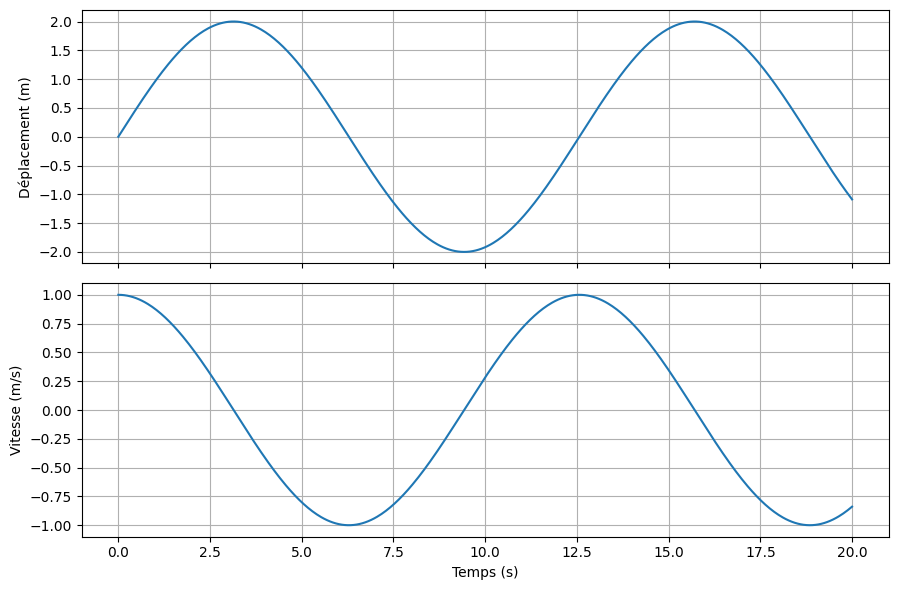

In [4]:
# loi de mouvement du réservoir
# Le cas utilise un mouvement de type solidBody avec oscillatingLinearMotion.
# La forme ci-dessous est une hypothèse analytique courante, mais il faut 
# confirmer la phase, l’origine temporelle et la convention de déplacement 
# avec le dictionnaire réel avant de la considérer comme définitive.

def tank_displacement(t):
    """
    Déplacement horizontal supposé :
        x_m(t) = A sin(omega*t + phase)

    À valider contre la loi exacte du cas OpenFOAM.
    """
    A = CFG["motion_amplitude"]
    omega = CFG["motion_omega"]
    phase = CFG["motion_phase"]

    return A * torch.sin(omega * t + phase)


def tank_velocity(t):
    """Vitesse horizontale du maillage : dx_m/dt."""
    A = CFG["motion_amplitude"]
    omega = CFG["motion_omega"]
    phase = CFG["motion_phase"]

    u_mesh = A * omega * torch.cos(omega * t + phase)
    v_mesh = torch.zeros_like(t)

    return u_mesh, v_mesh


t_plot = torch.linspace(
    CFG["t0"], CFG["t1"], 500, device=DEVICE
).reshape(-1, 1)

x_move = tank_displacement(t_plot).detach().cpu().numpy()
u_move, v_move = tank_velocity(t_plot)

fig, ax = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
ax[0].plot(t_plot.cpu().numpy(), x_move)
ax[0].set_ylabel("Déplacement (m)")
ax[0].grid(True)

ax[1].plot(t_plot.cpu().numpy(), u_move.detach().cpu().numpy())
ax[1].set_ylabel("Vitesse (m/s)")
ax[1].set_xlabel("Temps (s)")
ax[1].grid(True)

plt.tight_layout()
plt.show()
# Attention à l’interprétation du mouvement : dans un calcul ALE, 
# la vitesse du maillage n’est pas automatiquement la vitesse du fluide. 
# Le réseau prédit la vitesse du fluide et utilise séparément la vitesse 
# du maillage dans les termes de transport relatifs.

réseau de neurones

On utilise un réseau entièrement connecté prenant $(x,y,t)$ en entrée et prédisant $(u,v,p_{rgh},\alpha,k,\epsilon)$.

La pression reste non bornée ; 
la fraction volumique est bornée entre 0 et 1 ;
 $k$ et $\epsilon$ sont strictement positifs.

In [5]:

class SloshingPINN(nn.Module):
    def __init__(self, width=128, depth=6):
        super().__init__()

        layers = [
            nn.Linear(3, width),
            nn.Tanh()
        ]

        for _ in range(depth - 1):
            layers.extend([
                nn.Linear(width, width),
                nn.Tanh()
            ])

        layers.append(nn.Linear(width, 6))
        self.net = nn.Sequential(*layers)

    def forward(self, xyt):
        # Le réseau travaille sur les coordonnées normalisées.
        z = normalize_xyt(xyt)
        raw = self.net(z)

        u = raw[:, 0:1]
        v = raw[:, 1:2]
        p_rgh = raw[:, 2:3]

        alpha = torch.sigmoid(raw[:, 3:4])
        k = torch.nn.functional.softplus(raw[:, 4:5]) + 1e-8
        epsilon = torch.nn.functional.softplus(raw[:, 5:6]) + 1e-8

        return {
            "u": u,
            "v": v,
            "p_rgh": p_rgh,
            "alpha": alpha,
            "k": k,
            "epsilon": epsilon
        }


model = SloshingPINN(width=128, depth=6).to(DEVICE)

n_parameters = sum(p.numel() for p in model.parameters())
print(f"Nombre de paramètres : {n_parameters:,}")


Nombre de paramètres : 83,846


In [6]:
# dérivées automatiques
# Cette cellule définit les dérivées premières et secondes 
# nécessaires aux résidus des équations.
def derivative(y, x):
    return torch.autograd.grad(
        outputs=y,
        inputs=x,
        grad_outputs=torch.ones_like(y),
        create_graph=True,
        retain_graph=True
    )[0]


def partials(f, xyt):
    """
    Renvoie les dérivées dimensionnelles df/dx, df/dy, df/dt.
    xyt contient les coordonnées physiques (m, m, s).
    """
    df = derivative(f, xyt)
    return df[:, 0:1], df[:, 1:2], df[:, 2:3]


def divergence_2d(Fx, Fy, xyt):
    dFx = derivative(Fx, xyt)
    dFy = derivative(Fy, xyt)

    return dFx[:, 0:1] + dFy[:, 1:2]


def laplacian_2d(f, xyt):
    fx, fy, _ = partials(f, xyt)

    fxx = derivative(fx, xyt)[:, 0:1]
    fyy = derivative(fy, xyt)[:, 1:2]

    return fxx + fyy


In [7]:
# test des dérivées
# On vérifie les dérivées d’une fonction analytique connue
# avant de construire les résidus physiques.
xyt_test = torch.tensor(
    [
        [0.2, -0.1, 0.3],
        [0.4,  0.2, 0.7]
    ],
    device=DEVICE,
    requires_grad=True
)

f = (
    xyt_test[:, 0:1]**2
    + 3.0 * xyt_test[:, 1:2]
    + 2.0 * xyt_test[:, 2:3]
)

df = derivative(f, xyt_test)

expected = torch.cat(
    [
        2.0 * xyt_test[:, 0:1],
        3.0 * torch.ones_like(f),
        2.0 * torch.ones_like(f)
    ],
    dim=1
)

assert torch.allclose(df, expected, atol=1e-10)

print("Test d'autodifférentiation réussi.")
print("Dérivées calculées :")
print(df.detach().cpu().numpy())


Test d'autodifférentiation réussi.
Dérivées calculées :
[[0.4 3.  2. ]
 [0.8 3.  2. ]]


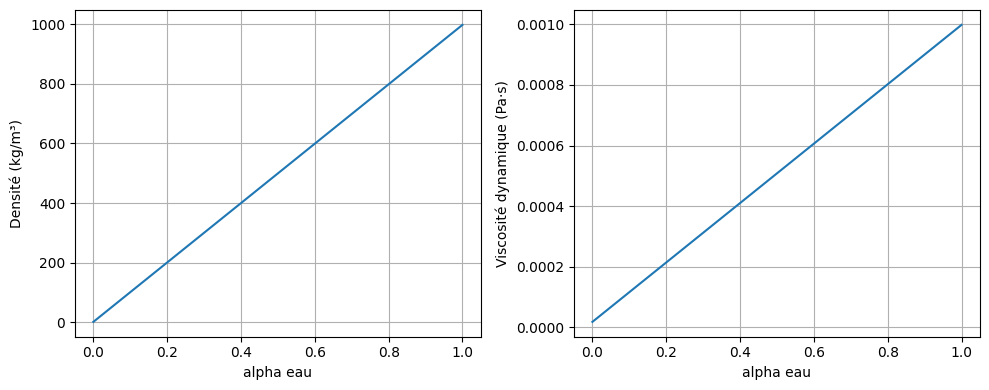

In [8]:
# propriétés du mélange
# On calcule la densité et la viscosité dynamique en fonction de
# alpha. Les valeurs utilisées ici proviennent des paramètres de 
# configuration et doivent rester cohérentes avec les propriétés 
# de phase du cas.
def mixture_properties(alpha):
    rho = (
        alpha * CFG["rho_water"]
        + (1.0 - alpha) * CFG["rho_air"]
    )

    mu = (
        alpha * CFG["mu_water"]
        + (1.0 - alpha) * CFG["mu_air"]
    )

    return rho, mu


alpha_demo = torch.linspace(0, 1, 101, device=DEVICE).reshape(-1, 1)
rho_demo, mu_demo = mixture_properties(alpha_demo)

fig, ax = plt.subplots(1, 2, figsize=(10, 4))

ax[0].plot(alpha_demo.cpu(), rho_demo.detach().cpu())
ax[0].set_xlabel("alpha eau")
ax[0].set_ylabel("Densité (kg/m³)")
ax[0].grid(True)

ax[1].plot(alpha_demo.cpu(), mu_demo.detach().cpu())
ax[1].set_xlabel("alpha eau")
ax[1].set_ylabel("Viscosité dynamique (Pa·s)")
ax[1].grid(True)

plt.tight_layout()
plt.show()


In [9]:
# résidus de continuité et de transport VOF
# Cette première fonction construit les résidus de continuité 
# et de transport. Le terme de compression est une approximation
#  continue destinée au PINN ; il ne reproduit pas exactement 
# le flux phirb ni les limiteurs MULES d’OpenFOAM.
def residual_alpha_continuity(model, xyt):
    if not xyt.requires_grad:
        xyt = xyt.detach().clone().requires_grad_(True)

    q = model(xyt)

    u = q["u"]
    v = q["v"]
    alpha = q["alpha"]

    u_mesh, v_mesh = tank_velocity(xyt[:, 2:3])

    u_rel = u - u_mesh
    v_rel = v - v_mesh

    alpha_x, alpha_y, alpha_t = partials(alpha, xyt)
    u_x, u_y, _ = partials(u, xyt)
    v_x, v_y, _ = partials(v, xyt)

    # Incompressibilité du champ de vitesse du fluide
    R_div = u_x + v_y

    # Flux compressif continu
    grad_norm = torch.sqrt(
        alpha_x**2 + alpha_y**2
        + CFG["interface_eps"]**2
    )

    nx = alpha_x / grad_norm
    ny = alpha_y / grad_norm

    speed_rel = torch.sqrt(
        u_rel**2 + v_rel**2 + 1e-12
    )

    Jcx = (
        CFG["c_alpha"]
        * speed_rel
        * alpha * (1.0 - alpha)
        * nx
    )

    Jcy = (
        CFG["c_alpha"]
        * speed_rel
        * alpha * (1.0 - alpha)
        * ny
    )

    # Forme conservative du transport relatif
    R_alpha = (
        alpha_t
        + divergence_2d(alpha * u_rel, alpha * v_rel, xyt)
        + divergence_2d(Jcx, Jcy, xyt)
    )

    return {
        "R_alpha": R_alpha,
        "R_div": R_div,
        "Jcx": Jcx,
        "Jcy": Jcy
    }


résidus de quantité de mouvement

On calcule les termes inertiels, le gradient de $p_{rgh}$, les contraintes visqueuses effectives et la force capillaire.
Le terme hydrostatique est écrit selon la convention $p_{rgh}=p-\rho g \cdot x$.

In [ ]:

def residual_momentum(model, xyt):
    if not xyt.requires_grad:
        xyt = xyt.detach().clone().requires_grad_(True)

    q = model(xyt)

    u = q["u"]
    v = q["v"]
    p_rgh = q["p_rgh"]
    alpha = q["alpha"]
    k = q["k"]
    epsilon = q["epsilon"]

    rho, mu = mixture_properties(alpha)

    # Dérivées de vitesse
    ux, uy, ut = partials(u, xyt)
    vx, vy, vt = partials(v, xyt)

    # Dérivées de pression réduite
    px, py, _ = partials(p_rgh, xyt)

    # Dérivées de densité
    rho_x, rho_y, _ = partials(rho, xyt)

    # Vitesse relative au maillage
    u_mesh, v_mesh = tank_velocity(xyt[:, 2:3])
    u_rel = u - u_mesh
    v_rel = v - v_mesh

    # Convection et accélération
    accel_x = ut + u_rel * ux + v_rel * uy
    accel_y = vt + u_rel * vx + v_rel * vy

    # Fermeture visqueuse effective
    if CFG["use_rans"]:
        mu_eff = (
            mu
            + rho * CFG["Cmu"] * k**2 / epsilon
        )
    else:
        mu_eff = mu

    # Contraintes newtoniennes effectives 2D
    tau_xx = 2.0 * mu_eff * ux
    tau_yy = 2.0 * mu_eff * vy
    tau_xy = mu_eff * (uy + vx)

    div_tau_x = divergence_2d(tau_xx, tau_xy, xyt)
    div_tau_y = divergence_2d(tau_xy, tau_yy, xyt)

    # Courbure de l'interface et force capillaire
    alpha_x, alpha_y, _ = partials(alpha, xyt)

    grad_alpha_norm = torch.sqrt(
        alpha_x**2 + alpha_y**2
        + CFG["interface_eps"]**2
    )

    nx = alpha_x / grad_alpha_norm
    ny = alpha_y / grad_alpha_norm

    kappa = -divergence_2d(nx, ny, xyt)

    if CFG["use_surface_tension"]:
        f_sigma_x = CFG["sigma"] * kappa * alpha_x
        f_sigma_y = CFG["sigma"] * kappa * alpha_y
    else:
        f_sigma_x = torch.zeros_like(u)
        f_sigma_y = torch.zeros_like(v)

    # Convention p_rgh = p - rho*(g . x)
    gh = (
        CFG["gx"] * xyt[:, 0:1]
        + CFG["gy"] * xyt[:, 1:2]
    )

    # -grad(p) + rho*g = -grad(p_rgh) - gh*grad(rho)
    hydro_x = gh * rho_x
    hydro_y = gh * rho_y

    R_mom_x = (
        rho * accel_x
        + px
        + hydro_x
        - div_tau_x
        - f_sigma_x
    )

    R_mom_y = (
        rho * accel_y
        + py
        + hydro_y
        - div_tau_y
        - f_sigma_y
    )

    return {
        "R_mom_x": R_mom_x,
        "R_mom_y": R_mom_y,
        "rho": rho,
        "mu": mu,
        "mu_eff": mu_eff,
        "kappa": kappa,
        "f_sigma_x": f_sigma_x,
        "f_sigma_y": f_sigma_y
    }

# Limite importante : la fermeture mu_eff ci-dessus est une première approximation.
# Pour prétendre reproduire la configuration RANS de ton cas, il faut également imposer
# les équations de transport de \(k\) et \(\epsilon\), avec les constantes et les
# conditions de paroi effectivement utilisées par OpenFOAM. La cellule suivante ajoute
# donc une version RANS de départ, pas une équivalence numérique garantie.


In [11]:
# résidus RANS \(k-\epsilon\) (approximation)
def residual_turbulence_kepsilon(model, xyt):
    """
    Forme continue RANS k-epsilon simplifiée.
    À vérifier contre la fermeture exacte OpenFOAM v2212,
    notamment les termes de production et les fonctions de paroi.
    """
    if not xyt.requires_grad:
        xyt = xyt.detach().clone().requires_grad_(True)

    q = model(xyt)
    u, v = q["u"], q["v"]
    alpha = q["alpha"]
    k, epsilon = q["k"], q["epsilon"]

    rho, mu = mixture_properties(alpha)
    u_mesh, v_mesh = tank_velocity(xyt[:, 2:3])
    u_rel, v_rel = u - u_mesh, v - v_mesh

    kx, ky, kt = partials(k, xyt)
    ex, ey, et = partials(epsilon, xyt)

    ux, uy, _ = partials(u, xyt)
    vx, vy, _ = partials(v, xyt)

    # Production approximative par cisaillement moyen
    Pk = mu * (
        2.0 * ux**2
        + 2.0 * vy**2
        + (uy + vx)**2
    )

    # Diffusivités turbulentes
    nut = CFG["Cmu"] * k**2 / epsilon
    mu_k = mu + rho * nut / 1.0  # sigma_k
    mu_eps = mu + rho * nut / CFG["sigma_epsilon"]

    # Flux convectifs relatifs
    conv_k = (
        kt
        + u_rel * kx
        + v_rel * ky
    )

    conv_eps = (
        et
        + u_rel * ex
        + v_rel * ey
    )

    # Flux diffusifs en forme conservative
    div_diff_k = divergence_2d(
        mu_k * kx, mu_k * ky, xyt
    )
    div_diff_eps = divergence_2d(
        mu_eps * ex, mu_eps * ey, xyt
    )

    R_k = (
        rho * conv_k
        - div_diff_k
        - Pk
        + rho * epsilon
    )

    R_eps = (
        rho * conv_eps
        - div_diff_eps
        - CFG["C1"] * epsilon * Pk / (k + 1e-10)
        + CFG["C2"] * rho * epsilon**2 / (k + 1e-10)
    )

    return {
        "R_k": R_k,
        "R_epsilon": R_eps
    }


In [12]:
# assembler les résidus physiques
def all_physics_residuals(model, xyt):
    r_vof = residual_alpha_continuity(model, xyt)
    r_mom = residual_momentum(model, xyt)

    residuals = {
        "alpha": r_vof["R_alpha"],
        "div": r_vof["R_div"],
        "mom_x": r_mom["R_mom_x"],
        "mom_y": r_mom["R_mom_y"]
    }

    if CFG["use_rans"]:
        r_turb = residual_turbulence_kepsilon(model, xyt)
        residuals["k"] = r_turb["R_k"]
        residuals["epsilon"] = r_turb["R_epsilon"]

    return residuals


def physics_loss(residuals, weights=None):
    if weights is None:
        weights = {
            "alpha": 1.0,
            "div": 1.0,
            "mom_x": 1.0,
            "mom_y": 1.0,
            "k": 1.0,
            "epsilon": 1.0
        }

    loss = torch.zeros((), device=DEVICE)

    for name, weight in weights.items():
        if name in residuals:
            loss = loss + weight * torch.mean(
                residuals[name]**2
            )

    return loss



## Conditions initiales et aux limites

Le cas utilise $p_{rgh}$ et non $p$.

La fraction volumique initiale est définie à partir de `alpha.eau` et
de `setFieldsDict`. Le niveau d'eau initial est à y = -0.5 m dans
la géométrie de travail ci-dessus.

Le champ $U$ est initialement au repos. Les parois mobiles utilisent
les conditions de vitesse associées au mouvement du maillage.
Le maillage est 2D avec une direction d'épaisseur de type empty.

Le champ $p_{rgh}$ possède sa propre condition de bord ; il ne faut pas
remplacer automatiquement cette condition par $p = 0$.

Pour construire les pertes aux limites, il faut distinguer :
1. les conditions de paroi mobiles ;
2. la condition du dessus du réservoir ;
3. la condition de pression ;
4. la condition initiale de alpha ;
5. les conditions de paroi de k et epsilon.

Ces conditions ne doivent pas être remplacées par des valeurs
arbitraires pour obtenir artificiellement une convergence.


In [13]:
# échantillonnage des points de collocation
rng = np.random.default_rng(CFG["seed"])

def sample_interior(n):
    x = rng.uniform(0.0, CFG["Lx"], size=(n, 1))
    y = rng.uniform(
        CFG["y_min"], CFG["y_max"], size=(n, 1)
    )
    t = rng.uniform(
        CFG["t0"], CFG["t1"], size=(n, 1)
    )

    points = np.hstack([x, y, t])

    return torch.tensor(
        points,
        dtype=torch.float64,
        device=DEVICE,
        requires_grad=True
    )


def sample_initial(n):
    x = rng.uniform(0.0, CFG["Lx"], size=(n, 1))
    y = rng.uniform(
        CFG["y_min"], CFG["y_max"], size=(n, 1)
    )
    t = np.full((n, 1), CFG["t0"])

    points = np.hstack([x, y, t])

    return torch.tensor(
        points,
        dtype=torch.float64,
        device=DEVICE,
        requires_grad=True
    )


def sample_boundary(n, side):
    t = rng.uniform(
        CFG["t0"], CFG["t1"], size=(n, 1)
    )

    if side == "left":
        x = np.zeros((n, 1))
        y = rng.uniform(CFG["y_min"], CFG["y_max"], (n, 1))
    elif side == "right":
        x = np.full((n, 1), CFG["Lx"])
        y = rng.uniform(CFG["y_min"], CFG["y_max"], (n, 1))
    elif side == "bottom":
        x = rng.uniform(0.0, CFG["Lx"], (n, 1))
        y = np.full((n, 1), CFG["y_min"])
    elif side == "top":
        x = rng.uniform(0.0, CFG["Lx"], (n, 1))
        y = np.full((n, 1), CFG["y_max"])
    else:
        raise ValueError("side doit être left/right/bottom/top")

    points = np.hstack([x, y, t])

    return torch.tensor(
        points,
        dtype=torch.float64,
        device=DEVICE,
        requires_grad=True
    )


X_f = sample_interior(2048)
X_0 = sample_initial(1024)

X_left = sample_boundary(512, "left")
X_right = sample_boundary(512, "right")
X_bottom = sample_boundary(512, "bottom")
X_top = sample_boundary(512, "top")

print("Intérieur :", X_f.shape)
print("Initial   :", X_0.shape)
print("Bords     :", X_left.shape, X_right.shape,
      X_bottom.shape, X_top.shape)


Intérieur : torch.Size([2048, 3])
Initial   : torch.Size([1024, 3])
Bords     : torch.Size([512, 3]) torch.Size([512, 3]) torch.Size([512, 3]) torch.Size([512, 3])


condition initiale de fraction volumique

La région d’eau est initialisée à $\alpha=1$ sous le niveau d’eau, et l’air à $\alpha=0$ au-dessus.


Cette fonction est un point de départ pour construire la perte initiale ;
elle doit être ajustée si setFieldsDict utilise d’autres bornes

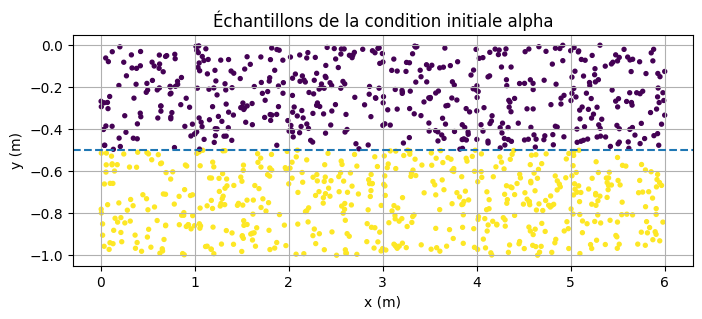

In [15]:

def alpha_initial(xyt):
    y = xyt[:, 1:2]
    return (y <= CFG["water_level"]).to(xyt.dtype)


def initial_condition_loss(model, xyt0):
    pred = model(xyt0)

    alpha_target = alpha_initial(xyt0)

    # Vitesse initiale supposée nulle dans le repère de départ.
    # À modifier si 0/U spécifie un état initial différent.
    u_target = torch.zeros_like(alpha_target)
    v_target = torch.zeros_like(alpha_target)

    loss_alpha = torch.mean(
        (pred["alpha"] - alpha_target)**2
    )
    loss_u = torch.mean((pred["u"] - u_target)**2)
    loss_v = torch.mean((pred["v"] - v_target)**2)

    return loss_alpha + loss_u + loss_v


alpha0_demo = alpha_initial(X_0).detach().cpu().numpy()

plt.figure(figsize=(8, 3))
plt.scatter(
    X_0[:, 0].detach().cpu().numpy(),
    X_0[:, 1].detach().cpu().numpy(),
    c=alpha0_demo[:, 0],
    s=8
)
plt.axhline(CFG["water_level"], linestyle="--")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.title("Échantillons de la condition initiale alpha")
plt.grid(True)
plt.show()


conditions de paroi mobile

Pour une paroi sans glissement qui se déplace avec le maillage, la vitesse du fluide à la paroi est égale à celle de la paroi. Cette perte ne remplace pas les conditions spécifiques du dessus ni les conditions de contact de l’interface.

In [16]:

def moving_wall_loss(model, xyt_wall):
    pred = model(xyt_wall)

    u_mesh, v_mesh = tank_velocity(
        xyt_wall[:, 2:3]
    )

    loss_u = torch.mean(
        (pred["u"] - u_mesh)**2
    )
    loss_v = torch.mean(
        (pred["v"] - v_mesh)**2
    )

    return loss_u + loss_v


def boundary_losses(model):
    """
    Perte provisoire pour les parois mobiles.
    Ne pas appliquer à une frontière ouverte sans vérifier le patch.
    """
    return (
        moving_wall_loss(model, X_left)
        + moving_wall_loss(model, X_right)
        + moving_wall_loss(model, X_bottom)
        + moving_wall_loss(model, X_top)
    )


In [17]:
test du modèle et des résidus

Cette cellule vérifie les dimensions et la différentiabilité du réseau. Elle n’effectue pas d’entraînement et ne constitue pas une validation physique.

SyntaxError: invalid character '’' (U+2019) (464372996.py, line 3)

In [22]:

model.eval()

# Petit lot pour limiter le coût des dérivées d'ordre supérieur
X_test = sample_interior(16)

q_test = model(X_test)

print("Sorties du réseau :")
for name, value in q_test.items():
    print(f"{name:>10s} : {tuple(value.shape)}")

# Les résidus de momentum et de turbulence impliquent
# des dérivées d'ordre supérieur ; le test peut prendre du temps.
r_test = all_physics_residuals(model, X_test)

print("\nRésidus calculés :")
for name, value in r_test.items():
    print(
        f"{name:>10s} : shape={tuple(value.shape)}, "
        f"finite={torch.isfinite(value).all().item()}"
    )

assert all(
    torch.isfinite(value).all()
    for value in r_test.values()
)

print("\nTest numérique passé : sorties finies et dimensions cohérentes.")
print("Cela ne prouve pas encore que les équations sont correctement résolues.")


Sorties du réseau :
         u : (16, 1)
         v : (16, 1)
     p_rgh : (16, 1)
     alpha : (16, 1)
         k : (16, 1)
   epsilon : (16, 1)

Résidus calculés :
     alpha : shape=(16, 1), finite=True
       div : shape=(16, 1), finite=True
     mom_x : shape=(16, 1), finite=True
     mom_y : shape=(16, 1), finite=True
         k : shape=(16, 1), finite=True
   epsilon : shape=(16, 1), finite=True

Test numérique passé : sorties finies et dimensions cohérentes.
Cela ne prouve pas encore que les équations sont correctement résolues.


perte physique

Les résidus ont des unités différentes et des échelles très différentes. Il faut les adimensionner ou définir des échelles caractéristiques avant de fixer les poids de perte. Les poids égaux ci-dessous servent uniquement à vérifier le fonctionnement du code.

In [23]:

def total_loss(model, X_f, X_0, weights=None):
    if weights is None:
        weights = {
            "alpha": 1.0,
            "div": 1.0,
            "mom_x": 1.0,
            "mom_y": 1.0,
            "k": 1.0,
            "epsilon": 1.0,
            "initial": 1.0,
            "walls": 1.0
        }

    residuals = all_physics_residuals(model, X_f)

    L_physics = physics_loss(
        residuals,
        weights={
            key: weights[key]
            for key in (
                "alpha", "div", "mom_x", "mom_y", "k", "epsilon"
            )
            if key in weights
        }
    )

    L_initial = initial_condition_loss(model, X_0)
    L_walls = boundary_losses(model)

    L_total = (
        L_physics
        + weights["initial"] * L_initial
        + weights["walls"] * L_walls
    )

    components = {
        "physics": L_physics,
        "initial": L_initial,
        "walls": L_walls,
        "total": L_total
    }

    return L_total, components


# Évaluation unique de la perte, sans mise à jour des poids
loss, parts = total_loss(model, X_f[:32], X_0[:32])

for name, value in parts.items():
    print(name, "=", value.detach().item())


physics = 461370.3516819993
initial = 0.2572458687837857
walls = 2.129126719601823
total = 461372.7380545877


boucle d’entraînement optionnelle
Ne lance pas encore cette boucle pour produire un modèle final. Elle est fournie comme squelette technique : les équations de turbulence, les conditions de bord, les échelles des résidus et la loi exacte du mouvement doivent d’abord être vérifiées.

In [24]:

def train_pinn(
    model,
    X_f,
    X_0,
    epochs=1000,
    learning_rate=1e-4,
    log_every=100
):
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate
    )

    history = {
        "total": [],
        "physics": [],
        "initial": [],
        "walls": []
    }

    for epoch in range(1, epochs + 1):
        model.train()
        optimizer.zero_grad()

        loss, parts = total_loss(model, X_f, X_0)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            model.parameters(), max_norm=100.0
        )
        optimizer.step()

        for name in history:
            history[name].append(
                parts[name].detach().item()
            )

        if epoch == 1 or epoch % log_every == 0:
            print(
                f"Epoch {epoch:5d} | "
                f"total={history['total'][-1]:.4e} | "
                f"physics={history['physics'][-1]:.4e} | "
                f"initial={history['initial'][-1]:.4e} | "
                f"walls={history['walls'][-1]:.4e}"
            )

    return history


# À exécuter uniquement après validation des équations et des BC :
#
# history = train_pinn(
#     model,
#     X_f,
#     X_0,
#     epochs=1000,
#     learning_rate=1e-4
# )


In [26]:
# À exécuter uniquement après validation des équations et des BC :

history = train_pinn(
    model,
    X_f,
    X_0,
    epochs=1000,
    learning_rate=1e-4
)

Epoch     1 | total=4.5954e+05 | physics=4.5954e+05 | initial=2.5879e-01 | walls=2.1291e+00
Epoch   100 | total=1.8317e+01 | physics=1.5528e+01 | initial=3.5715e-01 | walls=2.4314e+00
Epoch   200 | total=6.2418e+00 | physics=3.7127e+00 | initial=3.1218e-01 | walls=2.2169e+00
Epoch   300 | total=3.9571e+00 | physics=1.4840e+00 | initial=3.0414e-01 | walls=2.1690e+00
Epoch   400 | total=3.5407e+00 | physics=1.1186e+00 | initial=2.9783e-01 | walls=2.1243e+00
Epoch   500 | total=2.9329e+00 | physics=5.3960e-01 | initial=2.9587e-01 | walls=2.0974e+00
Epoch   600 | total=2.5002e+00 | physics=1.1660e-01 | initial=2.9671e-01 | walls=2.0869e+00
Epoch   700 | total=2.4499e+00 | physics=6.8020e-02 | initial=2.9655e-01 | walls=2.0853e+00
Epoch   800 | total=2.4270e+00 | physics=4.7190e-02 | initial=2.9498e-01 | walls=2.0848e+00
Epoch   900 | total=2.4124e+00 | physics=3.5536e-02 | initial=2.9247e-01 | walls=2.0844e+00
Epoch  1000 | total=2.4014e+00 | physics=2.8045e-02 | initial=2.8932e-01 | walls

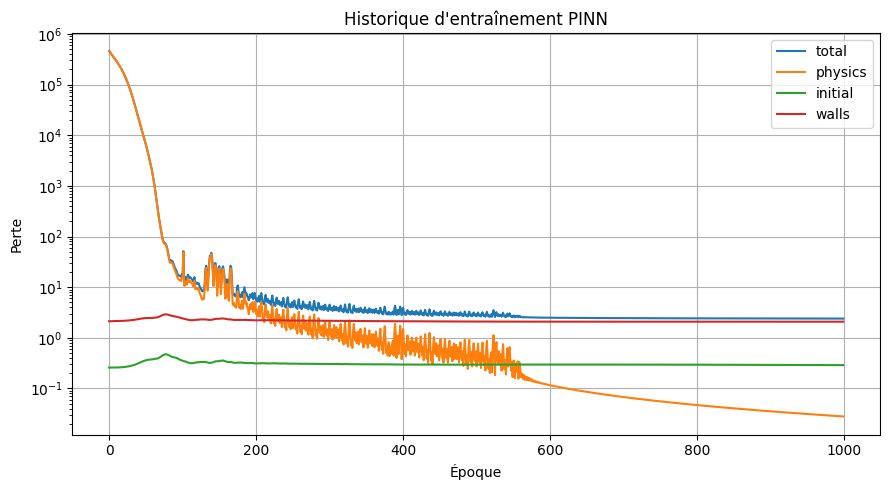

In [27]:
# Après entraînement :
plot_history(history)

In [25]:

def plot_history(history):
    fig, ax = plt.subplots(figsize=(9, 5))

    for name, values in history.items():
        ax.semilogy(
            np.maximum(values, 1e-16),
            label=name
        )

    ax.set_xlabel("Époque")
    ax.set_ylabel("Perte")
    ax.set_title("Historique d'entraînement PINN")
    ax.grid(True)
    ax.legend()
    plt.tight_layout()
    plt.show()


# Après entraînement :
# plot_history(history)


sauvegarde

In [28]:

OUTPUT_DIR = Path("../data")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

config_path = OUTPUT_DIR / "sinn_pinn_vof_config.json"

with open(config_path, "w", encoding="utf-8") as f:
    json.dump(CFG, f, indent=2)

print("Configuration enregistrée :", config_path)

# Ne sauvegarder un modèle entraîné qu'après validation.
torch.save(model.state_dict(), OUTPUT_DIR / "sinn_pinn_vof.pt")


Configuration enregistrée : ../data/sinn_pinn_vof_config.json



# Vérifications obligatoires avant entraînement

- [ ] Confirmer les dimensions et coordonnées de blockMeshDict.
- [ ] Vérifier la boîte initiale de setFieldsDict.
- [ ] Vérifier les conditions de 0/U, 0/p_rgh, 0/alpha.eau, 0/k et 0/epsilon.
- [ ] Vérifier les paramètres et la convention temporelle de dynamicMeshDict.
- [ ] Vérifier les schémas de transport VOF et la compression d'interface.
- [ ] Ajouter les conditions d'interface et de paroi réellement définies dans le cas.
- [ ] Compléter et vérifier les équations RANS k-epsilon.
- [ ] Vérifier l'état hydrostatique au repos avec la convention p_rgh.
- [ ] Tester les résidus sur une solution manufacturée avant le sloshing.
- [ ] Adimensionner les résidus et ajuster les poids des pertes.
- [ ] Geler le modèle avant toute comparaison aux résultats OpenFOAM.

La validation CFD doit être indépendante de l'entraînement :
aucun champ OpenFOAM ne doit entrer dans la perte du PINN de cette branche.
